# 01b · Separación BCG/ICL usando partículas del FoF completo

**Diferencia respecto a `01_separacion_BCG_ICL.ipynb`:**

| Versión | Fuente de partículas | Incluye |
|---------|---------------------|----------|
| `01_` | `loadSubhalo(bcg_sub_idx)` | Solo partículas del subhalo central (BCG puro según Subfind) |
| `01b_` | `loadHalo(fof_idx)` + máscara | Subhalo central + estrellas difusas no ligadas a satélites dentro del FoF |

**¿Por qué importa?**  
Subfind asigna partículas a subhalos por criterio de ligadura local. Las estrellas difusas que orbitan en el potencial del cúmulo pero que no están ligadas a ningún satélite en particular quedan **fuera del subhalo central** en `01_`, pero **dentro del FoF** en esta versión. Esas partículas son parte de la ICL real.

**Estrategia de máscara:**  
Las partículas dentro de un FoF están ordenadas contiguamente:  
`[subhalo 0 (central)] [subhalo 1 (sat)] ... [subhalo N-1 (sat)] [no ligadas al FoF]`  
Usamos `SubhaloLenType[:, 4]` (conteo de estrellas por subhalo) para excluir los bloques de satélites 1..N-1 y conservar el bloque 0 + el material no ligado.

In [5]:
import sys, os, pickle
import numpy as np
import h5py
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, './original_shift_code')
import illustris_python as il
import Catalogue
import params_icl as P

FIG_PDF = './figuras/01b_separacion_BCG_ICL_FoF/pdf'
FIG_PNG = './figuras/01b_separacion_BCG_ICL_FoF/png'
os.makedirs(FIG_PDF, exist_ok=True)
os.makedirs(FIG_PNG, exist_ok=True)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110,
                     'font.size': 12,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)

## Cargar catálogo + datos auxiliares del groupcat

In [6]:
# Catálogo ICL base (generado por 00_catalogo.ipynb)
with h5py.File(P.CATALOG_OUT, 'r') as f:
    group_idx     = f['group_idx'][:]       # índice FoF absoluto TNG
    M200c         = f['M200c_Msun'][:]
    R200c         = f['R200c_kpc'][:]
    GroupPos      = f['GroupPos_kpc'][:]
    bcg_sub_idx   = f['bcg_sub_idx'][:]     # GroupFirstSub = subfind ID del subhalo central
    t_last_merger = f['t_last_merger_Gyr'][:]
    dyn_state     = f['dyn_state'][:] if 'dyn_state' in f else None

n_cl = len(group_idx)
Header = il.groupcat.loadHeader(P.basePath, P.SNAP)

# Necesitamos GroupNsubs para saber cuántos subhalos tiene cada FoF
# y SubhaloLenType para construir la máscara de exclusión de satélites.
# Cargamos ambos UNA sola vez fuera del loop (eficiente).
print("Cargando GroupNsubs y GroupFirstSub del groupcat...")
halo_cat = il.groupcat.loadHalos(P.basePath, P.SNAP,
                                  fields=['GroupNsubs', 'GroupFirstSub'])
GroupNsubs    = halo_cat['GroupNsubs']     # número de subhalos por FoF
GroupFirstSub = halo_cat['GroupFirstSub']  # subfind ID del subhalo 0 de cada FoF

print("Cargando SubhaloLenType de todos los subhalos...")
sub_cat       = il.groupcat.loadSubhalos(P.basePath, P.SNAP,
                                          fields=['SubhaloLenType', 'SubhaloMassType'])
SubhaloLenType = sub_cat['SubhaloLenType']  # (N_sub_total, 6) — tipo 4 = estrellas

print(f"Catálogo cargado: {n_cl} cúmulos")
print(f"Total subhalos en TNG-100 snap {P.SNAP}: {len(SubhaloLenType):,}")

COLORS_STATE = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
LABELS_STATE = {0: 'Relajado', 1: 'Intermedio', 2: 'Perturbado'}

Cargando GroupNsubs y GroupFirstSub del groupcat...
Cargando SubhaloLenType de todos los subhalos...
Catálogo cargado: 166 cúmulos
Total subhalos en TNG-100 snap 99: 4,371,211


## Funciones auxiliares (mismas que en 01_)

In [7]:
def rotate_by_inertia_tensor(pos_rel, mass, r_lim=np.inf):
    """
    Alinea las partículas con los ejes principales del tensor de inercia reducido.
    Idéntica a la versión en 01_separacion_BCG_ICL.ipynb.
    """
    dist = np.linalg.norm(pos_rel, axis=1)
    ok   = (dist > 0) & (dist <= r_lim) & np.isfinite(mass)
    p, m = pos_rel[ok], mass[ok]

    if m.sum() == 0 or len(m) < 4:
        return pos_rel, np.eye(3)

    w    = 1.0 / dist[ok]**2
    mtot = np.sum(m)
    Ixx  = np.sum(m * p[:,0]**2 * w) / mtot
    Iyy  = np.sum(m * p[:,1]**2 * w) / mtot
    Izz  = np.sum(m * p[:,2]**2 * w) / mtot
    Ixy  = np.sum(m * p[:,0] * p[:,1] * w) / mtot
    Ixz  = np.sum(m * p[:,0] * p[:,2] * w) / mtot
    Iyz  = np.sum(m * p[:,1] * p[:,2] * w) / mtot
    I    = np.array([[Ixx, Ixy, Ixz],
                     [Ixy, Iyy, Iyz],
                     [Ixz, Iyz, Izz]])

    eigvals, eigvecs = np.linalg.eigh(I)
    idx    = np.argsort(eigvals)[::-1]
    R_mat  = eigvecs[:, idx].T
    pos_rot = pos_rel @ R_mat.T
    return pos_rot, R_mat


def sb_profile_r(r_2d, lum_r, r_max_kpc, n_bins=60):
    """
    Perfil 1D de brillo superficial en banda r.
    Idéntica a la versión en 01_separacion_BCG_ICL.ipynb.
    """
    r_bins = np.logspace(np.log10(0.5), np.log10(r_max_kpc), n_bins + 1)
    r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])
    mu_r   = np.full(n_bins, np.nan)

    for k, (r1, r2) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mk = (r_2d >= r1) & (r_2d < r2)
        if mk.sum() == 0:
            continue
        area_pc2 = np.pi * ((r2 * 1e3)**2 - (r1 * 1e3)**2)
        sigma_L  = lum_r[mk].sum() / area_pc2
        if sigma_L > 0:
            mu_r[k] = P.SB_CONST - 2.5 * np.log10(sigma_L)

    return r_mid, mu_r


def holmberg_radius(r_mid, mu_r, mu_cut=P.MU_HOLMBERG):
    """Interpola el radio donde μ_r = mu_cut."""
    valid = np.isfinite(mu_r) & (r_mid > 0)
    if valid.sum() < 3:
        return np.nan
    r_v, m_v = r_mid[valid], mu_r[valid]
    idx_s = np.argsort(r_v)
    r_v, m_v = r_v[idx_s], m_v[idx_s]
    if m_v[0] > mu_cut or m_v[-1] < mu_cut:
        return np.nan
    try:
        f = interp1d(m_v, r_v, kind='linear', fill_value='extrapolate')
        r_h = float(f(mu_cut))
        return r_h if 0 < r_h <= r_v[-1] * 1.2 else np.nan
    except Exception:
        return np.nan

## Función principal: cargar partículas del FoF excluyendo satélites

Esta es la diferencia central respecto a `01_`. En vez de `loadSubhalo`, usamos `loadHalo` y luego construimos una máscara booleana para quedarnos solo con:
- **Subhalo 0** (BCG central)
- **Partículas no ligadas** a ningún subhalo dentro del FoF (ICL difusa real)

Excluimos los bloques de partículas de los subhalos 1..N-1 (satélites).

In [8]:
def build_fof_mask_no_satellites(fof_idx):
    """
    Construye una máscara booleana sobre las partículas estelares del FoF
    para excluir las que pertenecen a subhalos satélites (1..N-1).

    Las partículas dentro de un FoF están ordenadas así en TNG:
      [subhalo 0] [subhalo 1] ... [subhalo N-1] [no ligadas]

    Retorna:
        mask : array bool (N_stars_FoF,) — True = conservar
        n_central : int — estrellas del subhalo central
        n_unbound : int — estrellas no ligadas a ningún subhalo
        n_satellites : int — estrellas excluidas (satélites)
    """
    first_sub = GroupFirstSub[fof_idx]   # subfind ID del subhalo 0
    n_subs    = GroupNsubs[fof_idx]      # total subhalos en este FoF

    # Conteo de partículas estelares (tipo 4) por subhalo en este FoF
    # SubhaloLenType ya está cargado globalmente — solo sliceamos
    if n_subs > 0:
        lens_star = SubhaloLenType[first_sub : first_sub + n_subs, 4].astype(int)
    else:
        lens_star = np.array([], dtype=int)

    total_in_subhalos = int(lens_star.sum())
    n_central   = int(lens_star[0]) if len(lens_star) > 0 else 0
    n_satellites = total_in_subhalos - n_central

    # El total de estrellas del FoF lo sabremos al cargar; construimos la máscara
    # en dos partes: True para bloque 0, False para bloques 1..N-1, True para resto
    # Devolvemos los tamaños de cada bloque para construirla después de loadHalo.
    return lens_star, n_central, n_satellites


def mask_from_lens(lens_star, n_total_fof):
    """
    Dado el array de longitudes por subhalo (lens_star) y el total de estrellas
    en el FoF, construye la máscara booleana:
      True  = subhalo 0 (central) + partículas no ligadas
      False = subhalos 1..N-1 (satélites)
    """
    mask = np.zeros(n_total_fof, dtype=bool)

    # Bloque del subhalo central (posición 0)
    n_central = int(lens_star[0]) if len(lens_star) > 0 else n_total_fof
    mask[:n_central] = True

    # Saltar los bloques de satélites (1..N-1)
    total_in_subhalos = int(lens_star.sum())

    # Partículas no ligadas a ningún subhalo (al final del bloque FoF)
    if total_in_subhalos < n_total_fof:
        mask[total_in_subhalos:] = True

    return mask


def bcg_icl_mass_fraction_fof(fof_idx, cen_pos, header=Header):
    """
    Carga todas las partículas estelares del FoF, excluye satélites,
    aplica el corte de Holmberg y devuelve (f_ICL, M_BCG, M_ICL) en M☉.

    Diferencia con bcg_icl_mass_fraction() de 01_:
      - Usa loadHalo en vez de loadSubhalo
      - Incluye ICL difusa no ligada a ningún subhalo
    """
    try:
        fields = ['Coordinates', 'Masses', 'GFM_StellarPhotometrics']
        st = il.snapshot.loadHalo(P.basePath, P.SNAP, int(fof_idx), 'stars',
                                   fields=fields)

        # loadHalo puede devolver 0 si el FoF no tiene estrellas
        if isinstance(st, int) or st is None:
            return np.nan, np.nan, np.nan

        n_total = len(st['Masses'])
        if n_total == 0:
            return np.nan, np.nan, np.nan

        # Construir máscara para excluir satélites
        lens_star, n_central, n_sat = build_fof_mask_no_satellites(fof_idx)
        mask = mask_from_lens(lens_star, n_total)

        # Aplicar máscara
        pos_raw  = st['Coordinates'][mask] * P.UL
        mass     = st['Masses'][mask] * P.UM

        phot = st['GFM_StellarPhotometrics'][mask]
        if phot.ndim == 1:
            phot = phot.reshape(-1, 8)
        lum  = 10**((P.M_SUN_R_AB - phot[:, 5]) / 2.5)

        # Centrar respecto al BCG y corregir periodicidad
        pos = Catalogue.Distance_3D(pos_raw, cen_pos, header['BoxSize'] * P.UL)

        # Rotar al plano del eje mayor
        pos_rot, _ = rotate_by_inertia_tensor(pos, mass)
        r2 = np.sqrt(pos_rot[:,0]**2 + pos_rot[:,1]**2)

        # Perfil de brillo superficial y radio de Holmberg
        r_m, mu = sb_profile_r(r2, lum, np.percentile(r2, 99))
        r_h = holmberg_radius(r_m, mu)
        if not np.isfinite(r_h):
            return np.nan, np.nan, np.nan

        m_bcg = mass[r2 <= r_h].sum()
        m_icl = mass[r2 >  r_h].sum()
        m_tot = m_bcg + m_icl
        return (m_icl / m_tot, m_bcg, m_icl) if m_tot > 0 else (np.nan, np.nan, np.nan)

    except Exception as e:
        print(f"    [WARN] fof_idx={fof_idx}  error: {e}")
        return np.nan, np.nan, np.nan

## Demostración con un cúmulo

Mismo cúmulo demo que en `01_` (el más masivo) para poder comparar directamente.

In [14]:
i_demo   = 0  # mismo índice que en 01_ para comparación directa
fof_demo = int(group_idx[i_demo])
cen      = GroupPos[i_demo]

print(f"Cúmulo demo: local i={i_demo}, fof_idx TNG={fof_demo}")
print(f"log M200c = {np.log10(M200c[i_demo]):.2f}  R200c = {R200c[i_demo]:.1f} kpc")
print()

# Cargar TODAS las estrellas del FoF
fields = ['Coordinates', 'Masses', 'GFM_StellarPhotometrics']
st_fof = il.snapshot.loadHalo(P.basePath, P.SNAP, fof_demo, 'stars', fields=fields)
n_fof_total = len(st_fof['Masses'])

# Máscara para excluir satélites
lens_star, n_central, n_sat = build_fof_mask_no_satellites(fof_demo)
mask = mask_from_lens(lens_star, n_fof_total)
n_unbound = mask.sum() - n_central

print(f"Partículas estelares en el FoF:")
print(f"  Total FoF         : {n_fof_total:>8,}")
print(f"  Subhalo central   : {n_central:>8,}  (conservadas)")
print(f"  Satélites (excl.) : {n_sat:>8,}  (excluidas)")
print(f"  No ligadas        : {n_unbound:>8,}  (conservadas — ICL difusa)")
print(f"  Usadas para perfil: {mask.sum():>8,}")

Cúmulo demo: local i=0, fof_idx TNG=0
log M200c = 14.58  R200c = 1523.0 kpc

Partículas estelares en el FoF:
  Total FoF         : 11,816,696
  Subhalo central   : 3,987,343  (conservadas)
  Satélites (excl.) : 7,823,406  (excluidas)
  No ligadas        :    5,947  (conservadas — ICL difusa)
  Usadas para perfil: 3,993,290


In [15]:
# Aplicar máscara y preparar arrays
pos_raw = st_fof['Coordinates'][mask] * P.UL
mass    = st_fof['Masses'][mask] * P.UM
phot    = st_fof['GFM_StellarPhotometrics'][mask]
if phot.ndim == 1:
    phot = phot.reshape(-1, 8)
lum_r = 10**((P.M_SUN_R_AB - phot[:, 5]) / 2.5)

# Centrar y corregir periodicidad
pos_c = Catalogue.Distance_3D(pos_raw, cen, Header['BoxSize'] * P.UL)

# Rotar al plano del eje mayor
pos_rot, R_mat = rotate_by_inertia_tensor(pos_c, mass)
r_2d = np.sqrt(pos_rot[:, 0]**2 + pos_rot[:, 1]**2)

# Perfil de brillo superficial
r_max    = np.percentile(r_2d, 99)
r_mid, mu_r = sb_profile_r(r_2d, lum_r, r_max)

# Radio de Holmberg
r_h = holmberg_radius(r_mid, mu_r)

# Separación BCG/ICL
M_bcg_demo = mass[r_2d <= r_h].sum()
M_icl_demo = mass[r_2d >  r_h].sum()
f_icl_demo = M_icl_demo / (M_bcg_demo + M_icl_demo)

print(f"Radio de Holmberg : {r_h:.1f} kpc")
print(f"f_ICL (FoF)       : {f_icl_demo:.3f}")
print()
print("Comparación con 01_ (solo subhalo central):")
print("  → Diferencia esperada: f_ICL_FoF >= f_ICL_subhalo")
print("    porque incluimos estrellas difusas no ligadas a satélites")

Radio de Holmberg : 237.9 kpc
f_ICL (FoF)       : 0.226

Comparación con 01_ (solo subhalo central):
  → Diferencia esperada: f_ICL_FoF >= f_ICL_subhalo
    porque incluimos estrellas difusas no ligadas a satélites


### Figura 1 – Perfil de brillo superficial 1D (versión FoF)

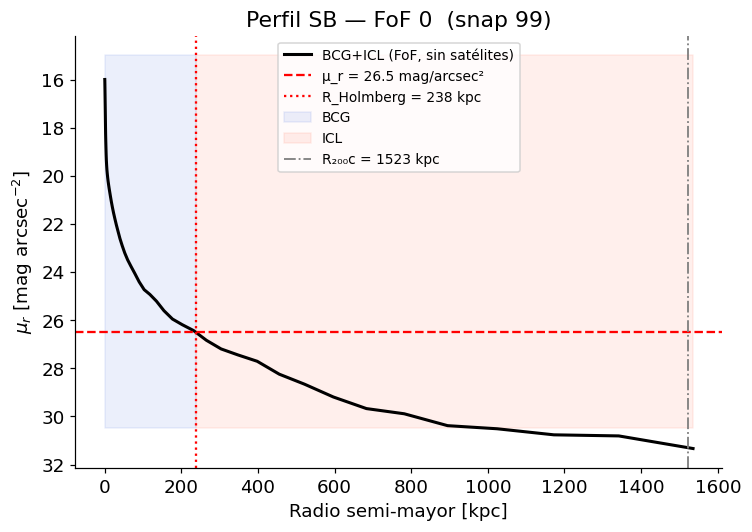

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(mu_r)

ax.plot(r_mid[valid], mu_r[valid], 'k-', lw=2, label='BCG+ICL (FoF, sin satélites)')
ax.axhline(P.MU_HOLMBERG, color='r', ls='--', lw=1.5,
           label=f'μ_r = {P.MU_HOLMBERG} mag/arcsec²')
if np.isfinite(r_h):
    ax.axvline(r_h, color='r', ls=':', lw=1.5,
               label=f'R_Holmberg = {r_h:.0f} kpc')
    ax.fill_betweenx([mu_r[valid].min()-1, P.MU_HOLMBERG+4],
                      0, r_h, alpha=0.10, color='royalblue', label='BCG')
    ax.fill_betweenx([mu_r[valid].min()-1, P.MU_HOLMBERG+4],
                      r_h, r_mid[valid][-1], alpha=0.10, color='tomato', label='ICL')
ax.axvline(R200c[i_demo], color='gray', ls='-.', lw=1.2,
           label=f'R₂₀₀c = {R200c[i_demo]:.0f} kpc')

ax.invert_yaxis()
ax.set_xlabel('Radio semi-mayor [kpc]')
ax.set_ylabel(r'$\mu_r$ [mag arcsec$^{-2}$]')
ax.set_title(f'Perfil SB — FoF {fof_demo}  (snap {P.SNAP})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01b_perfil_sb_FoF_haloid{fof_demo}_snap{P.SNAP}.pdf',
            bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01b_perfil_sb_FoF_haloid{fof_demo}_snap{P.SNAP}.png',
            bbox_inches='tight', dpi=150)
plt.show()

### Figura 2 – Mapa 2D de brillo superficial (versión FoF)

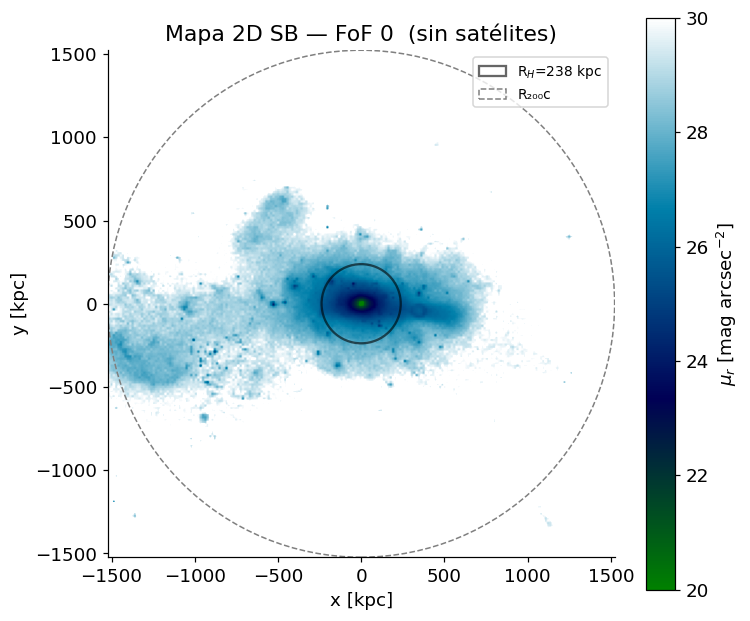

In [17]:
from scipy.stats import binned_statistic_2d

r_plot  = R200c[i_demo]
n_pix   = 216
edges   = np.linspace(-r_plot, r_plot, n_pix + 1)
pix_pc2 = ((2 * r_plot / n_pix) * 1e3)**2

H, _, _, _ = binned_statistic_2d(pos_rot[:, 0], pos_rot[:, 1],
                                   lum_r, statistic='sum',
                                   bins=[edges, edges])

with np.errstate(divide='ignore', invalid='ignore'):
    sigma  = np.where(H > 0, H / pix_pc2, np.nan)
    mu_map = np.where(sigma > 0, P.SB_CONST - 2.5 * np.log10(sigma), np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mu_map.T, origin='lower', cmap='ocean',
               extent=[-r_plot, r_plot, -r_plot, r_plot],
               vmin=20, vmax=30)
plt.colorbar(im, ax=ax, label=r'$\mu_r$ [mag arcsec$^{-2}$]')
if np.isfinite(r_h):
    ax.add_patch(plt.Circle((0, 0), r_h, fill=False, color='black',
                              lw=1.5, label=f'R$_H$={r_h:.0f} kpc', alpha=0.6))
ax.add_patch(plt.Circle((0, 0), r_plot, fill=False, color='gray',
                          lw=1, ls='--', label='R₂₀₀c'))
ax.set_xlabel('x [kpc]'); ax.set_ylabel('y [kpc]')
ax.set_title(f'Mapa 2D SB — FoF {fof_demo}  (sin satélites)')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01b_mapa_sb_FoF_haloid{fof_demo}_snap{P.SNAP}.pdf',
            bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01b_mapa_sb_FoF_haloid{fof_demo}_snap{P.SNAP}.png',
            bbox_inches='tight', dpi=150)
plt.show()

## Calcular f_ICL (FoF) para todos los cúmulos

In [18]:
icl_frac_fof = np.full(n_cl, np.nan)
M_bcg_fof    = np.full(n_cl, np.nan)
M_icl_fof    = np.full(n_cl, np.nan)

print("Calculando fracciones de masa ICL (versión FoF)...")
for i in range(n_cl):
    fof_i = int(group_idx[i])
    icl_frac_fof[i], M_bcg_fof[i], M_icl_fof[i] = \
        bcg_icl_mass_fraction_fof(fof_i, GroupPos[i])
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{n_cl}  f_ICL_med={np.nanmedian(icl_frac_fof[:i+1]):.3f}",
              end="\r")

n_ok  = np.sum(np.isfinite(icl_frac_fof))
n_nan = n_cl - n_ok
print(f"\n  Completados: {n_ok}/{n_cl}  ({n_nan} con NaN)")

# Guardar en el catálogo con nombres distintos para no pisar los de 01_
try:
    with h5py.File(P.CATALOG_OUT, 'a') as f:
        for k, v in [('icl_frac_fof',  icl_frac_fof),
                     ('M_bcg_fof_Msun', M_bcg_fof),
                     ('M_icl_fof_Msun', M_icl_fof)]:
            if k in f:
                del f[k]
            f.create_dataset(k, data=v)
    print(f"Guardado en: {P.CATALOG_OUT}")
    print(f"  f_ICL_FoF = {np.nanmean(icl_frac_fof):.3f} ± {np.nanstd(icl_frac_fof):.3f}")
except Exception as e:
    print(f"[ERROR] No se pudo guardar: {e}")
    print("  Variables disponibles en memoria: icl_frac_fof, M_bcg_fof, M_icl_fof")

Calculando fracciones de masa ICL (versión FoF)...
  160/166  f_ICL_med=0.161
  Completados: 166/166  (0 con NaN)
Guardado en: ./catalogo_icl.hdf5
  f_ICL_FoF = 0.170 ± 0.057


### Figura 3 – f_ICL (FoF) vs M₂₀₀c

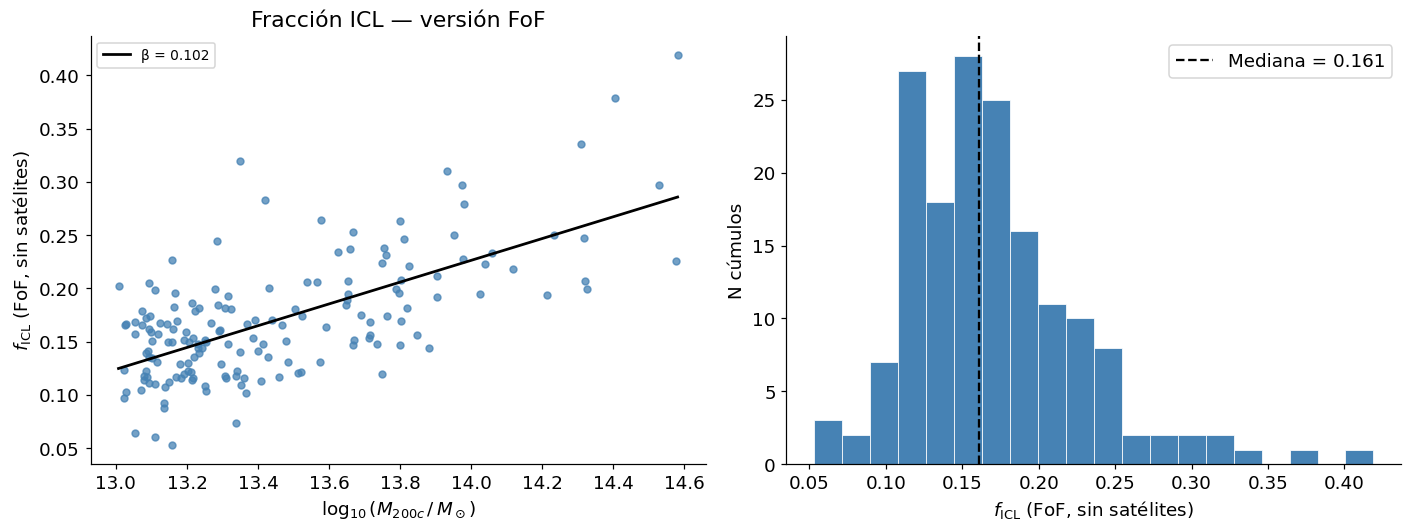

In [19]:
def linfit(x, y, log_x=True):
    xx = np.log10(x) if log_x else np.asarray(x)
    yy = np.asarray(y)
    ok = np.isfinite(xx) & np.isfinite(yy)
    sl, ic, *_ = linregress(xx[ok], yy[ok])
    return sl, ic, xx[ok], yy[ok]

lM = np.log10(M200c)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if dyn_state is not None:
    for s in [0, 1, 2]:
        m = dyn_state == s
        ax.scatter(lM[m], icl_frac_fof[m], color=COLORS_STATE[s],
                   label=LABELS_STATE[s], s=20, alpha=0.75)
else:
    ax.scatter(lM, icl_frac_fof, color='steelblue', s=20, alpha=0.75)

sl, ic, lx, ly = linfit(M200c, icl_frac_fof)
xx = np.linspace(lx.min(), lx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$f_{\rm ICL}$ (FoF, sin satélites)')
ax.set_title('Fracción ICL — versión FoF')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(icl_frac_fof[np.isfinite(icl_frac_fof)], bins=20,
        color='steelblue', edgecolor='white', lw=0.5)
ax.axvline(np.nanmedian(icl_frac_fof), ls='--', color='k', lw=1.5,
           label=f'Mediana = {np.nanmedian(icl_frac_fof):.3f}')
ax.set_xlabel(r'$f_{\rm ICL}$ (FoF, sin satélites)')
ax.set_ylabel('N cúmulos')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01b_icl_fof_vs_masa.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01b_icl_fof_vs_masa.png', bbox_inches='tight', dpi=150)
plt.show()

### Figura 4 – Comparación directa: f_ICL (subhalo central) vs f_ICL (FoF)

Esta figura es exclusiva de `01b_` — muestra qué tan diferente es el resultado según la fuente de partículas.

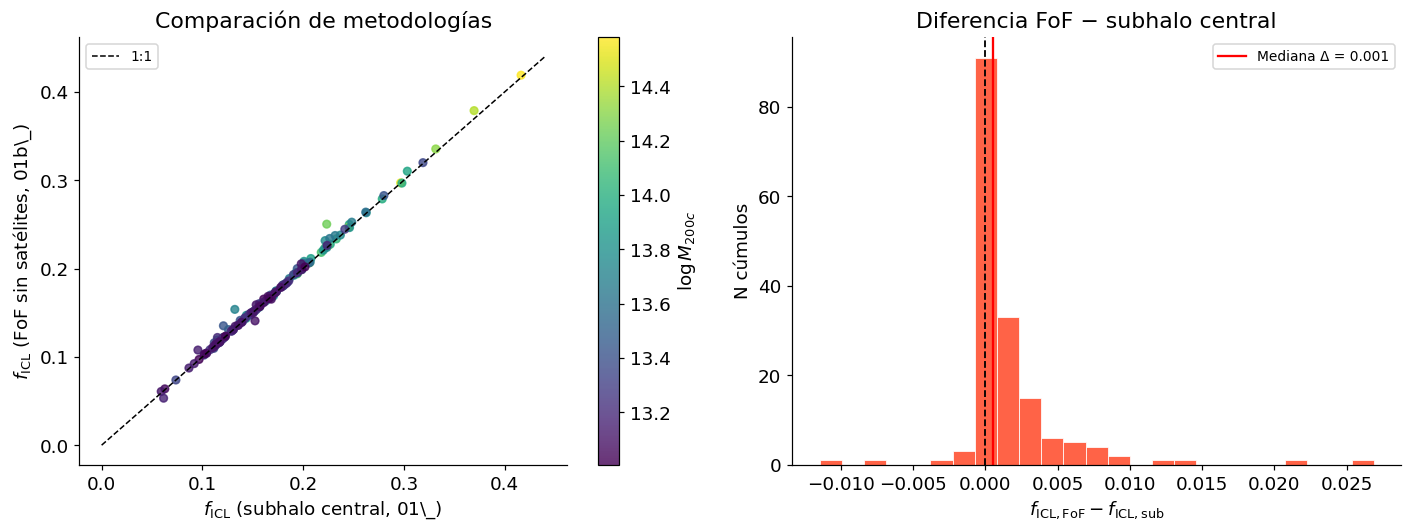

Δf_ICL medio (FoF − subhalo): 0.0016 ± 0.0037
Cúmulos donde FoF > subhalo : 154 / 166


In [20]:
# Cargar f_ICL de 01_ si ya fue guardado en el catálogo
try:
    with h5py.File(P.CATALOG_OUT, 'r') as f:
        icl_frac_sub = f['icl_frac'][:] if 'icl_frac' in f else None
except Exception:
    icl_frac_sub = None

if icl_frac_sub is not None:
    valid = np.isfinite(icl_frac_sub) & np.isfinite(icl_frac_fof)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    sc = ax.scatter(icl_frac_sub[valid], icl_frac_fof[valid],
                    c=lM[valid], cmap='viridis', s=25, alpha=0.8)
    plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')
    lim = [0, max(icl_frac_sub[valid].max(), icl_frac_fof[valid].max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1, label='1:1')
    ax.set_xlabel(r'$f_{\rm ICL}$ (subhalo central, 01\_)')
    ax.set_ylabel(r'$f_{\rm ICL}$ (FoF sin satélites, 01b\_)')
    ax.set_title('Comparación de metodologías')
    ax.legend(fontsize=9)

    ax = axes[1]
    delta = icl_frac_fof[valid] - icl_frac_sub[valid]
    ax.hist(delta, bins=25, color='tomato', edgecolor='white', lw=0.5)
    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.axvline(np.median(delta), color='red', lw=1.5,
               label=f'Mediana Δ = {np.median(delta):.3f}')
    ax.set_xlabel(r'$f_{\rm ICL,FoF} - f_{\rm ICL,sub}$')
    ax.set_ylabel('N cúmulos')
    ax.set_title('Diferencia FoF − subhalo central')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{FIG_PDF}/fig01b_comparacion_FoF_vs_subhalo.pdf', bbox_inches='tight')
    plt.savefig(f'{FIG_PNG}/fig01b_comparacion_FoF_vs_subhalo.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Δf_ICL medio (FoF − subhalo): {np.mean(delta):.4f} ± {np.std(delta):.4f}")
    print(f"Cúmulos donde FoF > subhalo : {(delta > 0).sum()} / {valid.sum()}")
else:
    print("No se encontró 'icl_frac' en el catálogo. Corre primero 01_separacion_BCG_ICL.ipynb.")

### Figura 5 – f_ICL (FoF) vs tiempo desde el último merger mayor

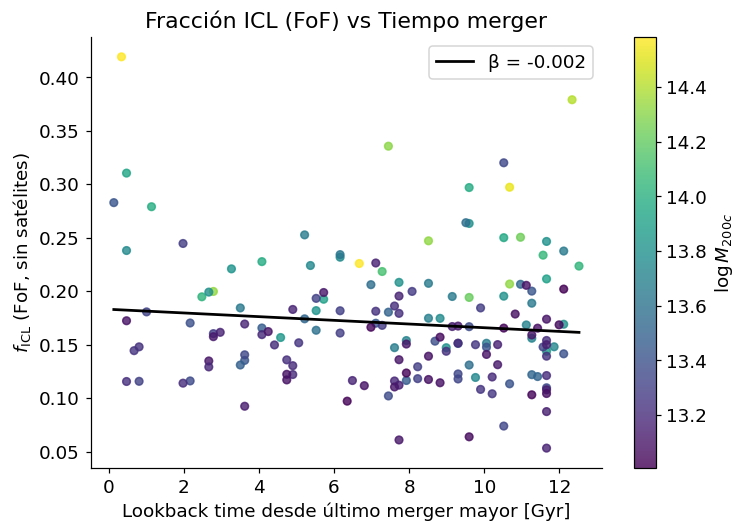

β = -0.002  (positivo → más tiempo desde merger = mayor f_ICL ✓)


In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(t_last_merger) & np.isfinite(icl_frac_fof)
sc = ax.scatter(t_last_merger[valid], icl_frac_fof[valid],
                c=lM[valid], cmap='viridis', s=25, alpha=0.8)
plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')

sl, ic, tx, ty = linfit(t_last_merger[valid], icl_frac_fof[valid], log_x=False)
xx = np.linspace(tx.min(), tx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel('Lookback time desde último merger mayor [Gyr]')
ax.set_ylabel(r'$f_{\rm ICL}$ (FoF, sin satélites)')
ax.set_title('Fracción ICL (FoF) vs Tiempo merger')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01b_icl_fof_vs_merger.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01b_icl_fof_vs_merger.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"β = {sl:.3f}  (positivo → más tiempo desde merger = mayor f_ICL ✓)")